# %% [markdown]
# # 03 — VEGA: Earth → Venus → Earth → Jupiter
# 
# Venus-Earth gravity assist. The Venus flyby pumps up the spacecraft's 
# heliocentric energy, setting up an Earth return flyby at higher V∞ that
# then sends the spacecraft toward Jupiter.
#
# **Sequence:** Earth → Venus → Earth → Jupiter (3 legs, 2 flybys)
#
# **IMPORTANT**: pykep's mga_1dsm stores velocities in **m/s** internally.
# All reporting converts to km/s.

In [2]:
# %% Cell 1 — Imports and setup
import numpy as np
import matplotlib.pyplot as plt
import pykep as pk
import pygmo as pg

print(f"pykep version: {pk.__version__}")
print(f"pygmo version: {pg.__version__}")

pykep version: {'major': 2, 'minor': 6}
pygmo version: 2.19.7


In [3]:
# %% Cell 2 — Define the MGA-1DSM problem
#
# Sequence: Earth → Venus → Earth → Jupiter
# Leg 1 (E→V): ~0.3 to 1.5 years (inner transfer)
# Leg 2 (V→E): ~0.5 to 2.0 years (return to Earth)
# Leg 3 (E→J): ~1.5 to 5.0 years (outer transfer)

seq = [
    pk.planet.jpl_lp('earth'),    # departure
    pk.planet.jpl_lp('venus'),    # flyby 1
    pk.planet.jpl_lp('earth'),    # flyby 2
    pk.planet.jpl_lp('jupiter'),  # arrival
]

udp = pk.trajopt.mga_1dsm(
    seq=seq,
    t0=[pk.epoch_from_string('2030-01-01 00:00:00'),
        pk.epoch_from_string('2038-01-01 00:00:00')],
    tof=[[100, 500],      # Leg 1: E→V (days)
         [100, 700],      # Leg 2: V→E (days)
         [500, 2200]],    # Leg 3: E→J (days)
    vinf=[0.5, 6.0],      # departure V∞ bounds (km/s)
    add_vinf_dep=True,
    add_vinf_arr=True,
    tof_encoding='direct',
    multi_objective=False,
)

prob = pg.problem(udp)
print(prob)

Problem name: MGA_1DSM Trajectory
	C++ class name: pybind11::object

	Global dimension:			14
	Integer dimension:			0
	Fitness dimension:			1
	Number of objectives:			1
	Equality constraints dimension:		0
	Inequality constraints dimension:	0
	Lower bounds: [10958, 0, 0, 500, 0.1, ... ]
	Upper bounds: [13880, 1, 1, 6000, 0.9, ... ]
	Has batch fitness evaluation: false

	Has gradient: false
	User implemented gradient sparsity: false
	Has hessians: false
	User implemented hessians sparsity: false

	Fitness evaluations: 0

	Thread safety: none

Extra info:

	 Sequence: ['earth', 'venus', 'earth', 'jupiter']
	 Add launcher vinf to the objective?: True
	 Add final vinf to the objective?: True


In [4]:
# %% Cell 3 — Multi-restart global search
#
# 3 legs → 14-dimensional search space. Needs more exploration than 2-leg problem.

# --- Phase 1: Broad search ---
print("Phase 1: Broad search (many short random starts) ...")

algo_phase1 = pg.algorithm(pg.sade(gen=200))
algo_phase1.set_verbosity(0)

archi = pg.archipelago(algo=algo_phase1, prob=prob, n=96, pop_size=25)

for i in range(6):
    archi.evolve()
    archi.wait()
    best_so_far = min(isl.get_population().champion_f[0] for isl in archi)
    print(f"  Round {i+1}/6: best = {best_so_far/1000:.4f} km/s")

# Collect champions
phase1_f = [isl.get_population().champion_f[0] for isl in archi]
phase1_x = [isl.get_population().champion_x for isl in archi]

ranked = sorted(zip(phase1_f, phase1_x), key=lambda pair: pair[0])
top_seeds = ranked[:25]
print(f"\nPhase 1 complete. Top 5 solutions (km/s):")
for i, (f, x) in enumerate(top_seeds[:5]):
    print(f"  #{i+1}: {f/1000:.4f} km/s")

# --- Phase 2: Refine top seeds ---
print("\nPhase 2: Refining top 25 solutions ...")

algo_phase2 = pg.algorithm(pg.sade(gen=600))
algo_phase2.set_verbosity(0)

best_overall_f = float('inf')
best_overall_x = None

for i, (f_seed, x_seed) in enumerate(top_seeds):
    pop = pg.population(prob, size=25)
    pop.set_x(0, x_seed)
    pop = algo_phase2.evolve(pop)
    
    if pop.champion_f[0] < best_overall_f:
        best_overall_f = pop.champion_f[0]
        best_overall_x = pop.champion_x.copy()
    
    if (i + 1) % 5 == 0:
        print(f"  Refined {i+1}/25 seeds, best so far: {best_overall_f/1000:.4f} km/s")

# --- Phase 3: Local polish ---
print("\nPhase 3: Local refinement with Compass Search ...")

algo_local = pg.algorithm(pg.compass_search(max_fevals=80000, start_range=0.01, stop_range=1e-6))
algo_local.set_verbosity(0)

pop_final = pg.population(prob, size=1)
pop_final.set_x(0, best_overall_x)
pop_final = algo_local.evolve(pop_final)

best_f = pop_final.champion_f[0]
best_x = pop_final.champion_x.copy()

print(f"\nFinal best ΔV: {best_f/1000:.4f} km/s")


Phase 1: Broad search (many short random starts) ...
  Round 1/6: best = 15.7193 km/s
  Round 2/6: best = 14.8948 km/s
  Round 3/6: best = 13.9745 km/s
  Round 4/6: best = 13.0691 km/s
  Round 5/6: best = 12.8537 km/s
  Round 6/6: best = 12.7884 km/s

Phase 1 complete. Top 5 solutions (km/s):
  #1: 12.7884 km/s
  #2: 13.1411 km/s
  #3: 13.1483 km/s
  #4: 13.2761 km/s
  #5: 13.4090 km/s

Phase 2: Refining top 25 solutions ...
  Refined 5/25 seeds, best so far: 12.3664 km/s
  Refined 10/25 seeds, best so far: 12.3664 km/s
  Refined 15/25 seeds, best so far: 12.3664 km/s
  Refined 20/25 seeds, best so far: 12.3664 km/s
  Refined 25/25 seeds, best so far: 12.3664 km/s

Phase 3: Local refinement with Compass Search ...

Final best ΔV: 11.6959 km/s


In [5]:
# %% Cell 4 — Display best solution
print("=" * 60)
print("  VEGA — BEST SOLUTION")
print("=" * 60)
udp.pretty(best_x)
print("=" * 60)
print(f"\n  Objective (total ΔV): {best_f/1000:.4f} km/s")

  VEGA — BEST SOLUTION
First Leg: earth to venus
Departure: 2031-Feb-21 10:24:03.157567 (11374.433369879249 mjd2000) 
Duration: 276.6002518469064days
VINF: 0.5 km/sec
DSM after 97.92564254030542 days
DSM magnitude: 3298.5430625587414m/s

leg no. 2: venus to earth
Duration: 512.8642775723872days
Fly-by epoch: 2031-Nov-25 00:48:24.917140 (11651.033621726156 mjd2000) 
Fly-by radius: 1.5295178725739356 planetary radii
DSM after 219.99618019804083 days
DSM magnitude: 8.613313846717602m/s

leg no. 3: earth to jupiter
Duration: 2200.0days
Fly-by epoch: 2033-Apr-20 21:32:58.499394 (12163.897899298543 mjd2000) 
Fly-by radius: 1.1 planetary radii
DSM after 628.7716015260944 days
DSM magnitude: 6990.0086233703m/s

Arrival at jupiter
Arrival epoch: 2039-Apr-29 21:32:58.499394 (14363.897899298543 mjd2000) 
Arrival Vinf: 898.7799764141851m/s
Total mission time: 8.18470781497411 years (2989.4645294192937 days)

  Objective (total ΔV): 11.6959 km/s


In [6]:
# %% Cell 5 — Extract key values for trade study
#
# Decision vector for mga_1dsm (direct encoding, 3 legs):
#   [t0, u, v, Vinf, eta1, T1, beta2, rp2/rV2, eta2, T2, beta3, rp3/rV3, eta3, T3]
#   indices: 0  1  2   3     4    5     6       7      8    9     10      11     12   13

t0_mjd2000 = best_x[0]
vinf_dep_ms = best_x[3]
vinf_dep_kms = vinf_dep_ms / 1000.0
T1 = best_x[5]    # E→V (days)
T2 = best_x[9]    # V→E (days)
T3 = best_x[13]   # E→J (days)
etas = [best_x[4], best_x[8], best_x[12]]

launch_epoch  = pk.epoch(t0_mjd2000, 'mjd2000')
venus_epoch   = pk.epoch(t0_mjd2000 + T1, 'mjd2000')
earth_epoch   = pk.epoch(t0_mjd2000 + T1 + T2, 'mjd2000')
jupiter_epoch = pk.epoch(t0_mjd2000 + T1 + T2 + T3, 'mjd2000')

c3_dep = vinf_dep_kms ** 2
total_tof = T1 + T2 + T3

print("=" * 60)
print("  VEGA — KEY PARAMETERS")
print("=" * 60)
print(f"  Launch:          {launch_epoch}")
print(f"  Venus flyby:     {venus_epoch}")
print(f"  Earth flyby:     {earth_epoch}")
print(f"  Jupiter arrival: {jupiter_epoch}")
print(f"  Leg 1 TOF (E→V): {T1:.1f} days ({T1/365.25:.2f} yr)")
print(f"  Leg 2 TOF (V→E): {T2:.1f} days ({T2/365.25:.2f} yr)")
print(f"  Leg 3 TOF (E→J): {T3:.1f} days ({T3/365.25:.2f} yr)")
print(f"  Total TOF:        {total_tof:.1f} days ({total_tof/365.25:.2f} yr)")
print(f"  C3 (departure):   {c3_dep:.2f} km²/s²")
print(f"  V∞ (departure):   {vinf_dep_kms:.3f} km/s")
print(f"  Total ΔV (obj):   {best_f/1000:.4f} km/s")
print("=" * 60)

# Flyby altitudes
venus_radius_km = 6052.0
earth_radius_km = 6378.0
venus_safe_r_km = seq[1].safe_radius / 1000.0
earth_safe_r_km = seq[2].safe_radius / 1000.0
venus_rp_ratio = best_x[7]
earth_rp_ratio = best_x[11]
venus_flyby_alt = venus_rp_ratio * venus_safe_r_km - venus_radius_km
earth_flyby_alt = earth_rp_ratio * earth_safe_r_km - earth_radius_km

print(f"\n  Venus flyby altitude: ~{venus_flyby_alt:.0f} km (rp ratio: {venus_rp_ratio:.2f})")
print(f"  Earth flyby altitude: ~{earth_flyby_alt:.0f} km (rp ratio: {earth_rp_ratio:.2f})")

# Sanity checks
print("\nSanity checks:")
if c3_dep > 50:
    print(f"  ⚠ C3 = {c3_dep:.1f} km²/s² — very high")
elif c3_dep > 30:
    print(f"  ⚠ C3 = {c3_dep:.1f} km²/s² — high, check FH performance curve")
else:
    print(f"  ✓ C3 = {c3_dep:.1f} km²/s² — reasonable")

  VEGA — KEY PARAMETERS
  Launch:          2031-Feb-21 10:24:03.157567
  Venus flyby:     2031-Nov-25 00:48:24.917140
  Earth flyby:     2033-Apr-20 21:32:58.499394
  Jupiter arrival: 2039-Apr-29 21:32:58.499394
  Leg 1 TOF (E→V): 276.6 days (0.76 yr)
  Leg 2 TOF (V→E): 512.9 days (1.40 yr)
  Leg 3 TOF (E→J): 2200.0 days (6.02 yr)
  Total TOF:        2989.5 days (8.18 yr)
  C3 (departure):   0.25 km²/s²
  V∞ (departure):   0.500 km/s
  Total ΔV (obj):   11.6959 km/s

  Venus flyby altitude: ~4130 km (rp ratio: 1.53)
  Earth flyby altitude: ~1339 km (rp ratio: 1.10)

Sanity checks:
  ✓ C3 = 0.2 km²/s² — reasonable


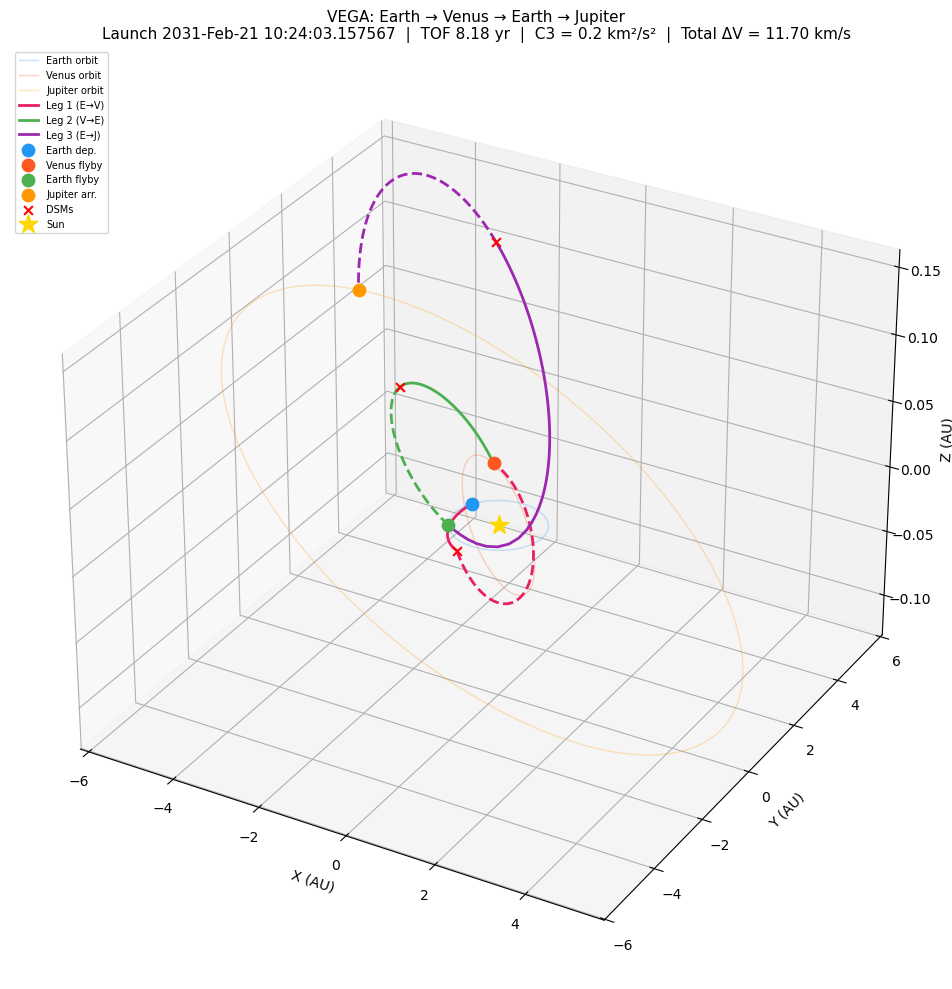

Saved: output/03_trajectory_vega.png
Saved: output/03_trajectory_vega.gif


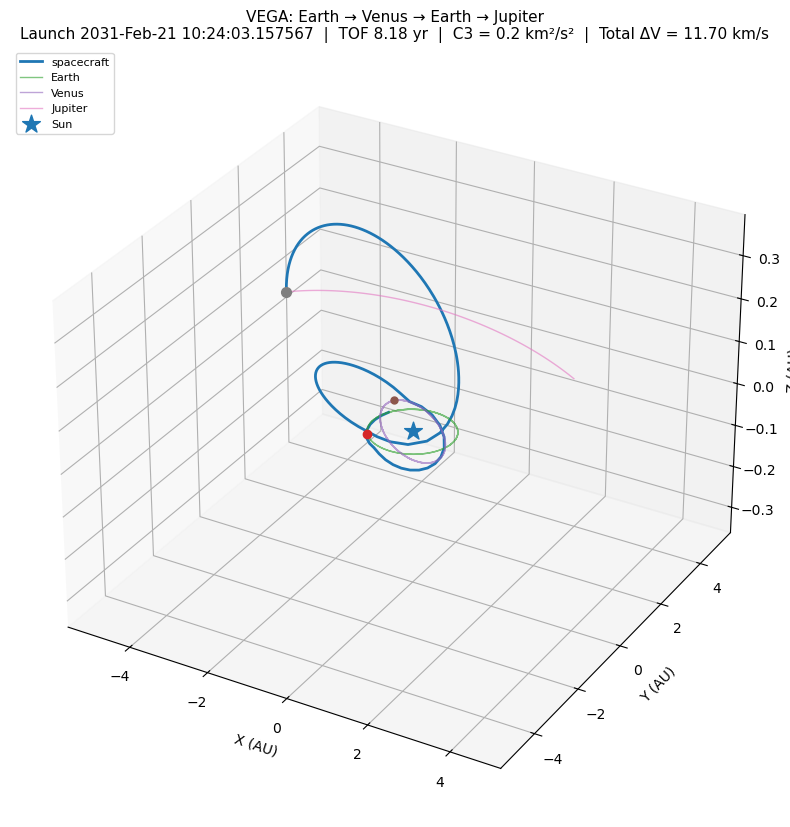

In [9]:
# %% Cell 6 — Trajectory plot (static) + animated GIF
from pykep import propagate_lagrangian, AU

# === Rebuild trajectory states ===
t0_mjd = t0_mjd2000
T_legs = [T1, T2, T3]

# Departure state
r_dep, v_dep_planet = seq[0].eph(pk.epoch(t0_mjd, 'mjd2000'))
theta = 2 * np.pi * best_x[1]
phi = np.arccos(2 * best_x[2] - 1) - np.pi / 2
Vinfx = vinf_dep_ms * np.cos(phi) * np.cos(theta)
Vinfy = vinf_dep_ms * np.cos(phi) * np.sin(theta)
Vinfz = vinf_dep_ms * np.sin(phi)
v0 = [v_dep_planet[0] + Vinfx, v_dep_planet[1] + Vinfy, v_dep_planet[2] + Vinfz]

# --- Leg 1: Earth to Venus ---
dt1_dsm_sec  = etas[0] * T1 * 86400.0
dt1_post_sec = (1 - etas[0]) * T1 * 86400.0

r1_dsm, v1_dsm = propagate_lagrangian(r_dep, v0, dt1_dsm_sec, pk.MU_SUN)

r_venus, v_venus_planet = seq[1].eph(pk.epoch(t0_mjd + T1, 'mjd2000'))
lamb1 = pk.lambert_problem(r1_dsm, r_venus, dt1_post_sec, pk.MU_SUN)
v1_post = lamb1.get_v1()[0]
v1_arr  = lamb1.get_v2()[0]  # arrival velocity at Venus

# --- Leg 2: Venus to Earth ---
# Post-flyby velocity: need to compute flyby turn
# V∞ in at Venus
vinf_in_venus = [v1_arr[i] - v_venus_planet[i] for i in range(3)]
vinf_in_mag = np.linalg.norm(vinf_in_venus)

# Use the flyby to compute outbound V∞ (simplified: use Lambert from Venus to Earth)
r_earth_fb, v_earth_fb_planet = seq[2].eph(pk.epoch(t0_mjd + T1 + T2, 'mjd2000'))

dt2_dsm_sec  = etas[1] * T2 * 86400.0
dt2_post_sec = (1 - etas[1]) * T2 * 86400.0

# For the flyby, we need the outbound V∞. Rather than manually computing the flyby,
# use Lambert for the full leg as approximation for the plot
lamb2_full = pk.lambert_problem(r_venus, r_earth_fb, T2 * 86400.0, pk.MU_SUN)
v2_depart_full = lamb2_full.get_v1()[0]  # approximate post-Venus departure velocity
v2_arr_full    = lamb2_full.get_v2()[0]

# Propagate leg 2 with DSM
r2_0 = r_venus
v2_0 = v2_depart_full

r2_dsm, v2_dsm = propagate_lagrangian(r2_0, v2_0, dt2_dsm_sec, pk.MU_SUN)
lamb2_post = pk.lambert_problem(r2_dsm, r_earth_fb, dt2_post_sec, pk.MU_SUN)
v2_post = lamb2_post.get_v1()[0]

# --- Leg 3: Earth to Jupiter ---
r_jupiter, v_jupiter_planet = seq[3].eph(pk.epoch(t0_mjd + T1 + T2 + T3, 'mjd2000'))

dt3_dsm_sec  = etas[2] * T3 * 86400.0
dt3_post_sec = (1 - etas[2]) * T3 * 86400.0

# Post-Earth-flyby: use Lambert for full leg as approximation
lamb3_full = pk.lambert_problem(r_earth_fb, r_jupiter, T3 * 86400.0, pk.MU_SUN)
v3_depart_full = lamb3_full.get_v1()[0]

r3_dsm, v3_dsm = propagate_lagrangian(r_earth_fb, v3_depart_full, dt3_dsm_sec, pk.MU_SUN)
lamb3_post = pk.lambert_problem(r3_dsm, r_jupiter, dt3_post_sec, pk.MU_SUN)
v3_post = lamb3_post.get_v1()[0]

# === Static plot ===
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

n_pts = 100

# Planet orbits
for planet, color, label in [(seq[0], '#2196F3', 'Earth orbit'),
                              (seq[1], '#FF5722', 'Venus orbit'),
                              (seq[3], '#FF9800', 'Jupiter orbit')]:
    period = planet.compute_period(pk.epoch(t0_mjd, 'mjd2000'))
    t_orb = np.linspace(0, period, 200)
    xo, yo, zo = [], [], []
    for dt in t_orb:
        r, _ = planet.eph(pk.epoch(t0_mjd + dt/86400.0, 'mjd2000'))
        xo.append(r[0]/AU); yo.append(r[1]/AU); zo.append(r[2]/AU)
    ax.plot(xo, yo, zo, color=color, alpha=0.25, linewidth=1, label=label)

# Leg 1 pre-DSM
arc_x, arc_y, arc_z = [], [], []
for frac in np.linspace(0, 1, n_pts):
    r, _ = propagate_lagrangian(r_dep, v0, frac * dt1_dsm_sec, pk.MU_SUN)
    arc_x.append(r[0]/AU); arc_y.append(r[1]/AU); arc_z.append(r[2]/AU)
ax.plot(arc_x, arc_y, arc_z, color='#E91E63', linewidth=2, label='Leg 1 (E→V)')

# Leg 1 post-DSM
arc_x, arc_y, arc_z = [], [], []
for frac in np.linspace(0, 1, n_pts):
    r, _ = propagate_lagrangian(r1_dsm, v1_post, frac * dt1_post_sec, pk.MU_SUN)
    arc_x.append(r[0]/AU); arc_y.append(r[1]/AU); arc_z.append(r[2]/AU)
ax.plot(arc_x, arc_y, arc_z, color='#E91E63', linewidth=2, linestyle='--')

# Leg 2 pre-DSM
arc_x, arc_y, arc_z = [], [], []
for frac in np.linspace(0, 1, n_pts):
    r, _ = propagate_lagrangian(r2_0, v2_0, frac * dt2_dsm_sec, pk.MU_SUN)
    arc_x.append(r[0]/AU); arc_y.append(r[1]/AU); arc_z.append(r[2]/AU)
ax.plot(arc_x, arc_y, arc_z, color='#4CAF50', linewidth=2, label='Leg 2 (V→E)')

# Leg 2 post-DSM
arc_x, arc_y, arc_z = [], [], []
for frac in np.linspace(0, 1, n_pts):
    r, _ = propagate_lagrangian(r2_dsm, v2_post, frac * dt2_post_sec, pk.MU_SUN)
    arc_x.append(r[0]/AU); arc_y.append(r[1]/AU); arc_z.append(r[2]/AU)
ax.plot(arc_x, arc_y, arc_z, color='#4CAF50', linewidth=2, linestyle='--')

# Leg 3 pre-DSM
arc_x, arc_y, arc_z = [], [], []
for frac in np.linspace(0, 1, n_pts):
    r, _ = propagate_lagrangian(r_earth_fb, v3_depart_full, frac * dt3_dsm_sec, pk.MU_SUN)
    arc_x.append(r[0]/AU); arc_y.append(r[1]/AU); arc_z.append(r[2]/AU)
ax.plot(arc_x, arc_y, arc_z, color='#9C27B0', linewidth=2, label='Leg 3 (E→J)')

# Leg 3 post-DSM
arc_x, arc_y, arc_z = [], [], []
for frac in np.linspace(0, 1, n_pts):
    r, _ = propagate_lagrangian(r3_dsm, v3_post, frac * dt3_post_sec, pk.MU_SUN)
    arc_x.append(r[0]/AU); arc_y.append(r[1]/AU); arc_z.append(r[2]/AU)
ax.plot(arc_x, arc_y, arc_z, color='#9C27B0', linewidth=2, linestyle='--')

# Encounter markers
encounters = [
    (r_dep, 'Earth dep.', '#2196F3'),
    (r_venus, 'Venus flyby', '#FF5722'),
    (r_earth_fb, 'Earth flyby', '#4CAF50'),
    (r_jupiter, 'Jupiter arr.', '#FF9800'),
]
for r_enc, lab, col in encounters:
    ax.scatter([r_enc[0]/AU], [r_enc[1]/AU], [r_enc[2]/AU],
               s=80, c=col, marker='o', label=lab, zorder=5)

# DSM markers
for r_d in [r1_dsm, r2_dsm, r3_dsm]:
    ax.scatter([r_d[0]/AU], [r_d[1]/AU], [r_d[2]/AU],
               s=40, c='red', marker='x', zorder=5)
ax.scatter([], [], [], s=40, c='red', marker='x', label='DSMs')  # legend entry

ax.scatter([0], [0], [0], s=200, c='gold', marker='*', label='Sun', zorder=10)
ax.set_xlabel('X (AU)'); ax.set_ylabel('Y (AU)'); ax.set_zlabel('Z (AU)')
ax.legend(fontsize=7, loc='upper left')
ax.set_title(f'VEGA: Earth → Venus → Earth → Jupiter\n'
             f'Launch {launch_epoch}  |  TOF {total_tof/365.25:.2f} yr  |  '
             f'C3 = {c3_dep:.1f} km²/s²  |  Total ΔV = {best_f/1000:.2f} km/s',
             fontsize=11)

plt.tight_layout()
plt.savefig('output/03_trajectory_vega.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: output/03_trajectory_vega.png")

# %% Cell 6b — Animated GIF
from matplotlib.animation import FuncAnimation, PillowWriter

fps = 12
days_per_frame = 12
max_frames = 450

# Time segments in seconds
seg1a = dt1_dsm_sec
seg1b = dt1_post_sec
seg2a = dt2_dsm_sec
seg2b = dt2_post_sec
seg3a = dt3_dsm_sec
seg3b = dt3_post_sec
t_total = seg1a + seg1b + seg2a + seg2b + seg3a + seg3b

seconds_per_frame = days_per_frame * 86400.0
n_frames = int(min(max_frames, np.ceil(t_total / seconds_per_frame))) + 1
t_grid = np.linspace(0.0, t_total, n_frames)

# Precompute positions
xs_sc = np.zeros(n_frames); ys_sc = np.zeros(n_frames); zs_sc = np.zeros(n_frames)
xe = np.zeros(n_frames); ye = np.zeros(n_frames); ze = np.zeros(n_frames)
xv = np.zeros(n_frames); yv = np.zeros(n_frames); zv = np.zeros(n_frames)
xjp = np.zeros(n_frames); yjp = np.zeros(n_frames); zjp = np.zeros(n_frames)

# Segment boundaries (cumulative seconds)
b1 = seg1a
b2 = b1 + seg1b
b3 = b2 + seg2a
b4 = b3 + seg2b
b5 = b4 + seg3a
# b6 = t_total

for k, t in enumerate(t_grid):
    # Spacecraft position
    if t <= b1:
        r, _ = propagate_lagrangian(r_dep, v0, t, pk.MU_SUN)
    elif t <= b2:
        r, _ = propagate_lagrangian(r1_dsm, v1_post, t - b1, pk.MU_SUN)
    elif t <= b3:
        r, _ = propagate_lagrangian(r2_0, v2_0, t - b2, pk.MU_SUN)
    elif t <= b4:
        r, _ = propagate_lagrangian(r2_dsm, v2_post, t - b3, pk.MU_SUN)
    elif t <= b5:
        r, _ = propagate_lagrangian(r_earth_fb, v3_depart_full, t - b4, pk.MU_SUN)
    else:
        r, _ = propagate_lagrangian(r3_dsm, v3_post, t - b5, pk.MU_SUN)
    
    xs_sc[k] = r[0]/AU; ys_sc[k] = r[1]/AU; zs_sc[k] = r[2]/AU

    # Planets at this time
    abs_mjd = t0_mjd + t / 86400.0
    ep = pk.epoch(abs_mjd, 'mjd2000')
    re, _ = seq[0].eph(ep); rv, _ = seq[1].eph(ep); rj, _ = seq[3].eph(ep)
    xe[k] = re[0]/AU; ye[k] = re[1]/AU; ze[k] = re[2]/AU
    xv[k] = rv[0]/AU; yv[k] = rv[1]/AU; zv[k] = rv[2]/AU
    xjp[k] = rj[0]/AU; yjp[k] = rj[1]/AU; zjp[k] = rj[2]/AU

# Animation
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

(sc_line,) = ax.plot([], [], [], linewidth=2, label='spacecraft')
(sc_dot,)  = ax.plot([], [], [], marker='o', markersize=5, linestyle='')

(tr_e,) = ax.plot([], [], [], linewidth=1, alpha=0.6, label='Earth')
(pt_e,) = ax.plot([], [], [], marker='o', markersize=6, linestyle='')
(tr_v,) = ax.plot([], [], [], linewidth=1, alpha=0.6, label='Venus')
(pt_v,) = ax.plot([], [], [], marker='o', markersize=5, linestyle='')
(tr_j,) = ax.plot([], [], [], linewidth=1, alpha=0.6, label='Jupiter')
(pt_j,) = ax.plot([], [], [], marker='o', markersize=7, linestyle='')

ax.scatter([0], [0], [0], s=180, marker='*', label='Sun', zorder=10)
ax.set_xlabel('X (AU)'); ax.set_ylabel('Y (AU)'); ax.set_zlabel('Z (AU)')
ax.legend(fontsize=8, loc='upper left')
ax.set_title(f'VEGA: Earth → Venus → Earth → Jupiter\n'
             f'Launch {launch_epoch}  |  TOF {total_tof/365.25:.2f} yr  |  '
             f'C3 = {c3_dep:.1f} km²/s²  |  Total ΔV = {best_f/1000:.2f} km/s',
             fontsize=11)

pad = 0.25
allx = np.concatenate([xs_sc, xe, xv, xjp])
ally = np.concatenate([ys_sc, ye, yv, yjp])
allz = np.concatenate([zs_sc, ze, zv, zjp])
ax.set_xlim(allx.min()-pad, allx.max()+pad)
ax.set_ylim(ally.min()-pad, ally.max()+pad)
ax.set_zlim(allz.min()-pad, allz.max()+pad)

trail_len = 80

def init():
    for obj in [sc_line, sc_dot, tr_e, pt_e, tr_v, pt_v, tr_j, pt_j]:
        obj.set_data([], [])
        obj.set_3d_properties([])
    return sc_line, sc_dot, tr_e, pt_e, tr_v, pt_v, tr_j, pt_j

def update(i):
    sc_line.set_data(xs_sc[:i+1], ys_sc[:i+1])
    sc_line.set_3d_properties(zs_sc[:i+1])
    sc_dot.set_data([xs_sc[i]], [ys_sc[i]])
    sc_dot.set_3d_properties([zs_sc[i]])

    j0 = max(0, i - trail_len)

    tr_e.set_data(xe[j0:i+1], ye[j0:i+1]); tr_e.set_3d_properties(ze[j0:i+1])
    pt_e.set_data([xe[i]], [ye[i]]); pt_e.set_3d_properties([ze[i]])

    tr_v.set_data(xv[j0:i+1], yv[j0:i+1]); tr_v.set_3d_properties(zv[j0:i+1])
    pt_v.set_data([xv[i]], [yv[i]]); pt_v.set_3d_properties([zv[i]])

    tr_j.set_data(xjp[j0:i+1], yjp[j0:i+1]); tr_j.set_3d_properties(zjp[j0:i+1])
    pt_j.set_data([xjp[i]], [yjp[i]]); pt_j.set_3d_properties([zjp[i]])

    return sc_line, sc_dot, tr_e, pt_e, tr_v, pt_v, tr_j, pt_j

anim = FuncAnimation(fig, update, frames=n_frames, init_func=init,
                     interval=1000/fps, blit=True)
anim.save('output/03_trajectory_vega.gif', writer=PillowWriter(fps=fps))
print("Saved: output/03_trajectory_vega.gif")
plt.show()

In [8]:
# %% Cell 7 — Convergence diagnostics
print("Solution vector breakdown (3-leg, 14 variables):")
print(f"  t0 (mjd2000):      {best_x[0]:.2f} → {launch_epoch}")
print(f"  u (V∞ dir):         {best_x[1]:.4f}")
print(f"  v (V∞ dir):         {best_x[2]:.4f}")
print(f"  V∞ dep:             {best_x[3]:.1f} m/s = {best_x[3]/1000:.3f} km/s")
print(f"  η1 (DSM1 timing):   {best_x[4]:.4f}")
print(f"  T1 (E→V days):      {best_x[5]:.1f}")
print(f"  β2 (Venus fb plane): {best_x[6]:.4f}")
print(f"  rp2/rV2 (Venus fb):  {best_x[7]:.4f}")
print(f"  η2 (DSM2 timing):   {best_x[8]:.4f}")
print(f"  T2 (V→E days):      {best_x[9]:.1f}")
print(f"  β3 (Earth fb plane): {best_x[10]:.4f}")
print(f"  rp3/rV3 (Earth fb):  {best_x[11]:.4f}")
print(f"  η3 (DSM3 timing):   {best_x[12]:.4f}")
print(f"  T3 (E→J days):      {best_x[13]:.1f}")

print("\nBound checks:")
print(f"  T1: 100 ≤ {best_x[5]:.0f} ≤ 500   {'⚠ AT BOUND' if best_x[5] < 101 or best_x[5] > 499 else '✓'}")
print(f"  T2: 100 ≤ {best_x[9]:.0f} ≤ 700   {'⚠ AT BOUND' if best_x[9] < 101 or best_x[9] > 699 else '✓'}")
print(f"  T3: 500 ≤ {best_x[13]:.0f} ≤ 2200  {'⚠ AT BOUND' if best_x[13] < 501 or best_x[13] > 2199 else '✓'}")
vinf_kms = best_x[3] / 1000
print(f"  V∞: 0.5 ≤ {vinf_kms:.2f} ≤ 6.0 km/s  {'⚠ AT BOUND' if vinf_kms < 0.51 or vinf_kms > 5.99 else '✓'}")


Solution vector breakdown (3-leg, 14 variables):
  t0 (mjd2000):      11374.43 → 2031-Feb-21 10:24:03.157567
  u (V∞ dir):         0.4618
  v (V∞ dir):         0.7342
  V∞ dep:             500.0 m/s = 0.500 km/s
  η1 (DSM1 timing):   0.3540
  T1 (E→V days):      276.6
  β2 (Venus fb plane): -1.8649
  rp2/rV2 (Venus fb):  1.5295
  η2 (DSM2 timing):   0.4290
  T2 (V→E days):      512.9
  β3 (Earth fb plane): -1.5797
  rp3/rV3 (Earth fb):  1.1000
  η3 (DSM3 timing):   0.2858
  T3 (E→J days):      2200.0

Bound checks:
  T1: 100 ≤ 277 ≤ 500   ✓
  T2: 100 ≤ 513 ≤ 700   ✓
  T3: 500 ≤ 2200 ≤ 2200  ⚠ AT BOUND
  V∞: 0.5 ≤ 0.50 ≤ 6.0 km/s  ⚠ AT BOUND
